# 1.Load+EDA

In [1]:
import warnings
warnings.filterwarnings("ignore")
 
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_auc_score
import category_encoders as ce
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
 
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
df = pd.read_csv('data/training.csv')

In [3]:
df

,RefId,IsBadBuy,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,...,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,PRIMEUNIT,AUCGUART,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost
0,1,0,12/7/2009,ADESA,2006,3,MAZDA,MAZDA3,i,4D SEDAN I,...,11597.0,12409.0,NaN,NaN,21973,33619,FL,7100.0,0,1113
1,2,0,12/7/2009,ADESA,2004,5,DODGE,1500 RAM PICKUP 2WD,ST,QUAD CAB 4.7L SLT,...,11374.0,12791.0,NaN,NaN,19638,33619,FL,7600.0,0,1053
2,3,0,12/7/2009,ADESA,2005,4,DODGE,STRATUS V6,SXT,4D SEDAN SXT FFV,...,7146.0,8702.0,NaN,NaN,19638,33619,FL,4900.0,0,1389
3,4,0,12/7/2009,ADESA,2004,5,DODGE,NEON,SXT,4D SEDAN,...,4375.0,5518.0,NaN,NaN,19638,33619,FL,4100.0,0,630
4,5,0,12/7/2009,ADESA,2005,4,FORD,FOCUS,ZX3,2D COUPE ZX3,...,6739.0,7911.0,NaN,NaN,19638,33619,FL,4000.0,0,1020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72978,73010,1,12/2/2009,ADESA,2001,8,MERCURY,SABLE,GS,4D SEDAN GS,...,4836.0,5937.0,NaN,NaN,18111,30212,GA,4200.0,0,993
72979,73011,0,12/2/2009,ADESA,2007,2,CHEVROLET,MALIBU 4C,LS,4D SEDAN LS,...,10151.0,11652.0,NaN,NaN,18881,30212,GA,6200.0,0,1038
72980,73012,0,12/2/2009,ADESA,2005,4,JEEP,GRAND CHEROKEE 2WD V,Lar,4D WAGON LAREDO,...,11831.0,14402.0,NaN,NaN,18111,30212,GA,8200.0,0,1893
72981,73013,0,12/2/2009,ADESA,2006,3,CHEVROLET,IMPALA,LS,4D SEDAN LS,...,10099.0,11228.0,NaN,NaN,18881,30212,GA,7000.0,0,1974


In [4]:
df.describe()

,RefId,IsBadBuy,VehYear,VehicleAge,WheelTypeID,VehOdo,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,BYRNO,VNZIP1,VehBCost,IsOnlineSale,WarrantyCost
count,72983.000000,72983.000000,72983.000000,72983.000000,69814.000000,72983.000000,72965.000000,72965.000000,72965.000000,72965.000000,72668.000000,72668.000000,72668.000000,72668.000000,72983.000000,72983.000000,72983.000000,72983.000000,72983.000000
mean,36511.428497,0.122988,2005.343052,4.176644,1.494299,71499.995917,6128.909217,7373.636031,8497.034332,9850.928240,6132.081287,7390.681827,8775.723331,10145.385314,26345.842155,58043.059945,6730.934326,0.025280,1276.580985
std,21077.241302,0.328425,1.731252,1.712210,0.521290,14578.913128,2461.992768,2722.491986,3156.285284,3385.789541,2434.567723,2686.248852,3090.702941,3310.254351,25717.351219,26151.640415,1767.846435,0.156975,598.846788
min,1.000000,0.000000,2001.000000,0.000000,0.000000,4825.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,835.000000,2764.000000,1.000000,0.000000,462.000000
25%,18257.500000,0.000000,2004.000000,3.000000,1.000000,61837.000000,4273.000000,5406.000000,6280.000000,7493.000000,4275.000000,5414.000000,6536.000000,7784.000000,17212.000000,32124.000000,5435.000000,0.000000,837.000000
50%,36514.000000,0.000000,2005.000000,4.000000,1.000000,73361.000000,6097.000000,7303.000000,8444.000000,9789.000000,6062.000000,7313.000000,8729.000000,10103.000000,19662.000000,73108.000000,6700.000000,0.000000,1155.000000
75%,54764.500000,0.000000,2007.000000,5.000000,2.000000,82436.000000,7765.000000,9021.000000,10651.000000,12088.000000,7736.000000,9013.000000,10911.000000,12309.000000,22808.000000,80022.000000,7900.000000,0.000000,1623.000000
max,73014.000000,1.000000,2010.000000,9.000000,3.000000,115717.000000,35722.000000,36859.000000,39080.000000,41482.000000,35722.000000,36859.000000,39080.000000,41062.000000,99761.000000,99224.000000,45469.000000,1.000000,7498.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72983 entries, 0 to 72982
Data columns (total 34 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   RefId                              72983 non-null  int64  
 1   IsBadBuy                           72983 non-null  int64  
 2   PurchDate                          72983 non-null  object 
 3   Auction                            72983 non-null  object 
 4   VehYear                            72983 non-null  int64  
 5   VehicleAge                         72983 non-null  int64  
 6   Make                               72983 non-null  object 
 7   Model                              72983 non-null  object 
 8   Trim                               70623 non-null  object 
 9   SubModel                           72975 non-null  object 
 10  Color                              72975 non-null  object 
 11  Transmission                       72974 non-null  obj

In [6]:
print(f'Размер датасета: {df.shape}\n')
print(f'Распределение таргета:\n{df['IsBadBuy'].value_counts(normalize=True).round(3)}\n')
print(f'Пропуски:\n{df.isnull().sum().sort_values(ascending=False).head(17)}')

Размер датасета: (72983, 34)

Распределение таргета:
IsBadBuy
0    0.877
1    0.123
Name: proportion, dtype: float64

Пропуски:
AUCGUART                             69564
PRIMEUNIT                            69564
WheelType                             3174
WheelTypeID                           3169
Trim                                  2360
MMRCurrentRetailCleanPrice             315
MMRCurrentAuctionAveragePrice          315
MMRCurrentAuctionCleanPrice            315
MMRCurrentRetailAveragePrice           315
MMRAcquisitonRetailCleanPrice           18
MMRAcquisitionAuctionCleanPrice         18
MMRAcquisitionAuctionAveragePrice       18
MMRAcquisitionRetailAveragePrice        18
Transmission                             9
Color                                    8
SubModel                                 8
Nationality                              5
dtype: int64


# 2.Train / Valid / Test split by PurchDate

In [7]:
df['PurchDate'] = pd.to_datetime(df['PurchDate'])
df = df.sort_values('PurchDate').reset_index(drop=True)
dates = df['PurchDate'].unique()

n = len(dates)
t1 = dates[int(n / 3)]
t2 = dates[int(2 * n / 3)]

train = df[df['PurchDate'] < t1].copy()
valid = df[(df['PurchDate'] >= t1) & (df['PurchDate'] < t2)].copy()
test = df[df['PurchDate'] >= t2].copy()

In [8]:
print(f'Размах дат: {dates[0].date()} - {dates[-1].date()}')
print(f'Train: {len(train)} rows, {train['PurchDate'].min().date()} - {train['PurchDate'].max().date()}')
print(f'Valid: {len(valid)} rows, {valid['PurchDate'].min().date()} - {valid['PurchDate'].max().date()}')
print(f'Test: {len(test)} rows, {test['PurchDate'].min().date()} - {test['PurchDate'].max().date()}')

Размах дат: 2009-01-05 - 2010-12-30
Train: 23059 rows, 2009-01-05 - 2009-09-01
Valid: 24104 rows, 2009-09-02 - 2010-04-30
Test: 25820 rows, 2010-05-03 - 2010-12-30


In [9]:
TARGET = 'IsBadBuy'

y_tr = train[TARGET].values
y_va = valid[TARGET].values
y_te = test[TARGET].values

# 3. Preprocessing

In [10]:
DROP_COLS = ["RefId", "IsBadBuy", "PurchDate"]
 
CAT_COLS = [
    "Auction", "Make", "Model", "Trim", "SubModel", "Color",
    "Transmission", "WheelTypeID", "WheelType", "Nationality",
    "Size", "TopThreeAmericanName", "PRIMEUNIT", "AUCGUART",
    "BYRNO", "VNZIP1", "VNST"
]

NUM_COLS = [c for c in df.columns if c not in CAT_COLS + DROP_COLS]

print(f"Категориальных признаков: {len(CAT_COLS)}")
print(f"Числовых признаков: {len(NUM_COLS)}\n")

Категориальных признаков: 17
Числовых признаков: 14



In [11]:
from sklearn.preprocessing import OneHotEncoder
 
ohe = OneHotEncoder(handle_unknown="error", sparse_output=False)
ohe.fit(train[CAT_COLS].astype(str).fillna("NA"))
 
try:
    ohe.transform(valid[CAT_COLS].astype(str).fillna("NA"))
    print("  OHE(valid) - OK (нет OOV)")
except ValueError as e:
    print(f"  OHE(valid): ERROR — {str(e)[:120]}")

  OHE(valid): ERROR — Found unknown categories ['VOLVO', 'TOYOTA SCION'] in column 1 during transform


In [12]:
oov_detected = False

for col in CAT_COLS:
    tr_val = set(train[col].astype(str).unique())
    val_oov = set(valid[col].astype(str).unique()) - tr_val
    test_oov = set(test[col].astype(str).unique()) - tr_val

    if val_oov or test_oov:
        oov_detected = True
        print(f'OOV in {col}: valid={len(val_oov)}, test={len(test_oov)}')

if oov_detected:
    print('OOV значения найдены, лучше использовать CounterEncoder')
else:
    print('Нет OOV значений, можно пробовать использовать другие энкодеры')

OOV in Make: valid=2, test=1
OOV in Model: valid=219, test=210
OOV in Trim: valid=7, test=8
OOV in SubModel: valid=125, test=161
OOV in Transmission: valid=1, test=0
OOV in WheelTypeID: valid=0, test=1
OOV in Nationality: valid=1, test=0
OOV in Size: valid=1, test=0
OOV in TopThreeAmericanName: valid=1, test=0
OOV in PRIMEUNIT: valid=1, test=1
OOV in AUCGUART: valid=0, test=1
OOV in BYRNO: valid=24, test=36
OOV in VNZIP1: valid=24, test=34
OOV in VNST: valid=2, test=7
OOV значения найдены, лучше использовать CounterEncoder


In [ ]:
count_enc = ce.CountEncoder(
    cols=CAT_COLS,
    handle_unknown="value",
    handle_missing="value",
    normalize=False,
)

count_enc.fit(train[CAT_COLS])

def encode_split(split_df):
    cat_encoded = count_enc.transform(split_df[CAT_COLS].copy())
    num_part = split_df[NUM_COLS].copy()

    X = pd.concat([num_part.reset_index(drop=True), cat_encoded.reset_index(drop=True)], axis=1)

    return X

Xtr_raw = encode_split(train)
Xva_raw = encode_split(valid)
Xte_raw = encode_split(test)

col_medians = Xtr_raw.median()
Xtr_raw = Xtr_raw.fillna(col_medians)
Xva_raw = Xva_raw.fillna(col_medians)
Xte_raw = Xte_raw.fillna(col_medians)

scaler = StandardScaler()
X_tr = scaler.fit_transform(Xtr_raw)
X_va = scaler.transform(Xva_raw)
X_te = scaler.transform(Xte_raw)

print(f"X_train: {X_tr.shape}")
print(f"X_valid: {X_va.shape}")
print(f"X_test: {X_te.shape}\n")

X_train: (23059, 31)
X_valid: (24104, 31)
X_test:  (25820, 31)



# 5. Custom metrics

In [14]:
def roc_auc_custom(y_true, y_score):
    y_true, y_score = np.asarray(y_true), np.array(y_score)
    order = np.argsort(y_score)[::-1]
    y_true_sorted = y_true[order]

    n_pos = y_true.sum()
    n_neg = len(y_true) - n_pos

    tpr = np.cumsum(y_true_sorted) / n_pos
    fpr = np.cumsum(1 - y_true_sorted) / n_neg

    tpr = np.concatenate([[0], tpr])
    fpr = np.concatenate([[0], fpr])
    auc = np.trapezoid(tpr, fpr)

    return float(auc)


def gini_custom(y_true, y_score):
    return 2 * roc_auc_custom(y_true, y_score) - 1


def precision_recall_curve_custom(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    order = np.argsort(y_score)[::-1]
    y_sorted = y_true[order]
 
    tps = np.cumsum(y_sorted)
    fps = np.cumsum(1 - y_sorted)
 
    precision = tps / (tps + fps)
    recall = tps / y_true.sum()

    precision = np.concatenate([[1.0], precision])
    recall = np.concatenate([[0.0], recall])
    thresholds = np.sort(y_score)[::-1]
 
    return precision, recall, thresholds


def auc_pr_custom(y_true, y_score):
    precision, recall, _ = precision_recall_curve_custom(y_true, y_score)
    order = np.argsort(recall)
    
    return float(np.trapezoid(precision[order], recall[order]))
 
 
def recall_at_threshold(y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    
    return tp / (tp + fn + 1e-12)
 
 
def precision_at_threshold(y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    
    return tp / (tp + fp + 1e-12)
 
 
def f1_at_threshold(y_true, y_score, threshold=0.5):
    p = precision_at_threshold(y_true, y_score, threshold)
    r = recall_at_threshold(y_true, y_score, threshold)
    
    return 2 * p * r / (p + r + 1e-12)

In [15]:
_y = np.array([0, 0, 1, 1])
_sc = np.array([0.1, 0.4, 0.35, 0.8])
custom_auc = roc_auc_custom(_y, _sc)
sklearn_auc = roc_auc_score(_y, _sc)
print(f"Проверка\nCustom AUC: {custom_auc:.4f},  sklearn AUC: {sklearn_auc:.4f}")
print(f"Разница кастома и библиотечной: {abs(custom_auc - sklearn_auc):.6f}\n")

Проверка
Custom AUC: 0.7500,  sklearn AUC: 0.7500
Разница кастома и библиотечной: 0.000000



# 4. Baseline sklearn models

In [16]:
baseline_models = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000, C=1.0, solver="lbfgs", random_state=RANDOM_STATE
    ),
    "GaussianNB": GaussianNB(),
    "KNN (k=15)": KNeighborsClassifier(n_neighbors=15, n_jobs=-1),
}
 
baseline_results = {}
for name, model in baseline_models.items():
    model.fit(X_tr, y_tr)
    prob_valid = model.predict_proba(X_va)[:, 1]
    gini = gini_custom(y_va, prob_valid)
    auc = roc_auc_custom(y_va, prob_valid)
    baseline_results[name] = {"model": model, "gini_valid": gini, "auc_valid": auc}
    print(f"  {name:<25}  Gini={gini:.4f}  AUC={auc:.4f}")
 
best_baseline = max(baseline_results, key=lambda k: baseline_results[k]["gini_valid"])
print(f"\n  Best baseline: {best_baseline} (Gini={baseline_results[best_baseline]['gini_valid']:.4f})")

  LogisticRegression         Gini=0.4362  AUC=0.7181
  GaussianNB                 Gini=0.4557  AUC=0.7278
  KNN (k=15)                 Gini=0.3644  AUC=0.6822

  Best baseline: GaussianNB (Gini=0.4557)


Наивный байес обычно уступает логистической регрессии.  
Но есть предположение, что:     
- признаки близки к нормальным внутри каждого класса. GaussianNB предполагает нормальность, и если она реально есть, он оказывается близок к оптимальному байесовскому классификатору.
- мультиколлинеарность в данных. LR чувствительна к коррелированным признакам (коэффициенты «раздуваются»). NB игнорирует корреляции между признаками по определению («наивное» предположение), и иногда это случайно дает лучшую обобщаемость.   
- нелинейные разделения. Если классы разделены нелинейно, но плотности внутри них гауссовы, NB может давать более гладкую границу решений, чем линейная LR.

Однако даже если NB лидирует на бейзлайне, после добавления полиномиальных признаков, регуляризации или ансамблей, ситуация может измениться в сторону LR.

# 6. Custom implementations

In [ ]:
class MyLogisticRegression:
    """
    Binary Logistic Regression trained with mini-batch SGD.
 
    Loss: L = -[y*log(p) + (1-y)*log(1-p)]
    dL/dw = X.T @ (p - y) / n
    dL/db = mean(p - y)
    """
 
    def __init__(self, lr=0.01, n_epochs=50, batch_size=256,
                 C=1.0, random_state=42):
        self.lr = lr
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.C = C
        self.random_state = random_state
        self.w = None
        self.b = None
 
    @staticmethod
    def _sigmoid(z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -30, 30)))
 
    def fit(self, X, y):
        rng = np.random.default_rng(self.random_state)
        n, d = X.shape
        self.w = np.zeros(d)
        self.b = 0.0
 
        for epoch in range(self.n_epochs):
            idx = rng.permutation(n)
            X_shuf, y_shuf = X[idx], y[idx]
 
            for start in range(0, n, self.batch_size):
                Xb = X_shuf[start: start + self.batch_size]
                yb = y_shuf[start: start + self.batch_size].astype(float)
                nb = len(yb)
 
                p = self._sigmoid(Xb @ self.w + self.b)
                diff = p - yb
 
                dw = (Xb.T @ diff) / nb + (1.0 / self.C) * self.w / n
                db = diff.mean()
 
                self.w -= self.lr * dw
                self.b -= self.lr * db
 
        return self
 
    def predict_proba(self, X):
        p = self._sigmoid(X @ self.w + self.b)

        return np.column_stack([1 - p, p])
 
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)
 

class MyKNN:
    """
    K-Nearest Neighbors classifier.
    Uses Euclidean distance; prediction = majority vote (soft = mean of labels).
    """
 
    def __init__(self, k=15):
        self.k = k
        self.X_tr = None
        self.y_tr = None
 
    def fit(self, X, y):
        self.X_tr = np.asarray(X, dtype=float)
        self.y_tr = np.asarray(y, dtype=float)
        return self
 
    def _distances(self, X):
        chunk = 500
        dists = []
        for i in range(0, len(X), chunk):
            Xc = X[i: i + chunk]
            sq_a = (Xc ** 2).sum(axis=1, keepdims=True)
            sq_b = (self.X_tr ** 2).sum(axis=1)
            d2 = sq_a + sq_b - 2 * Xc @ self.X_tr.T
            dists.append(np.sqrt(np.maximum(d2, 0)))
        return np.vstack(dists)
 
    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        D = self._distances(X)
        nn_idx = np.argpartition(D, self.k, axis=1)[:, : self.k]
        nn_labels = self.y_tr[nn_idx]
        p_pos = nn_labels.mean(axis=1)
        return np.column_stack([1 - p_pos, p_pos])
 
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)
 
 
class MyGaussianNB:
    """
    Gaussian Naive Bayes.
    Fits per-class mean and variance for each feature;
    log-posterior = log-prior + sum of log Gaussian likelihoods.
    """
 
    def __init__(self, var_smoothing=1e-9):
        self.var_smoothing = var_smoothing
 
    def fit(self, X, y):
        X, y = np.asarray(X, dtype=float), np.asarray(y)
        self.classes_ = np.unique(y)
        self.priors_ = {}
        self.means_ = {}
        self.vars_ = {}
        for c in self.classes_:
            Xc = X[y == c]
            self.priors_[c] = len(Xc) / len(y)
            self.means_[c] = Xc.mean(axis=0)
            self.vars_[c] = Xc.var(axis=0) + self.var_smoothing
        return self
 
    def _log_likelihood(self, X, c):
        mu = self.means_[c]
        var = self.vars_[c]
        return -0.5 * np.sum(np.log(2 * np.pi * var) + (X - mu) ** 2 / var, axis=1)
 
    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        log_posts = []
        for c in self.classes_:
            lp = np.log(self.priors_[c]) + self._log_likelihood(X, c)
            log_posts.append(lp)
        log_posts = np.column_stack(log_posts)
        log_posts -= log_posts.max(axis=1, keepdims=True)
        probs = np.exp(log_posts)
        probs /= probs.sum(axis=1, keepdims=True)
        return probs
 
    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]

In [18]:
my_lr = MyLogisticRegression(lr=0.05, n_epochs=80, batch_size=512, C=1.0)
my_lr.fit(X_tr, y_tr)
 
N_KNN = 10000
my_knn = MyKNN(k=15)
my_knn.fit(X_tr[:N_KNN], y_tr[:N_KNN])

my_nb = MyGaussianNB()
my_nb.fit(X_tr, y_tr)

custom_models = {
    "MyLogisticRegression": my_lr,
    "MyKNN (k=15, N=10k)": my_knn,
    "MyGaussianNB": my_nb,
}
 
print("\n  Кастомные модели — validation Gini:")
for name, m in custom_models.items():
    prob = m.predict_proba(X_va)[:, 1]
    gini = gini_custom(y_va, prob)
    sk_auc = roc_auc_score(y_va, prob)
    check = abs(gini - abs(2 * sk_auc - 1))
    print(f"  {name:<20}  Gini={gini:.4f}   |check vs sklearn| = {check:.6f}")


  Кастомные модели — validation Gini:
  MyLogisticRegression  Gini=0.4523   |check vs sklearn| = 0.000000
  MyKNN (k=15, N=10k)   Gini=0.3621   |check vs sklearn| = 0.000039
  MyGaussianNB          Gini=0.4557   |check vs sklearn| = 0.000000


# 7. Feature Engineering

In [19]:
def engineer_features(df_raw, groupby_stats=None, fit=True):
    """
    Create non-linear features.
    groupby_stats: dict of precomputed stats (from train) to avoid leakage.
    Returns (new_df, groupby_stats).
    """
    df = df_raw.copy()
 
    eps = 1.0
 
    df["Price_ratio_AcqCleanVsAvg"] = (
        df["MMRAcquisitionAuctionCleanPrice"] /
        (df["MMRAcquisitionAuctionAveragePrice"] + eps)
    )
    df["Price_ratio_RetailVsAuction"] = (
        df["MMRAcquisitionRetailAveragePrice"] /
        (df["MMRAcquisitionAuctionAveragePrice"] + eps)
    )
    df["Price_ratio_CurrentVsAcq"] = (
        df["MMRCurrentAuctionAveragePrice"] /
        (df["MMRAcquisitionAuctionAveragePrice"] + eps)
    )
    df["Depreciation_AucAvg"] = (
        df["MMRAcquisitionAuctionAveragePrice"] -
        df["MMRCurrentAuctionAveragePrice"]
    )
    df["CostVsMMR"] = df["VehBCost"] / (df["MMRAcquisitionAuctionAveragePrice"] + eps)
    df["OdoPerYear"] = df["VehOdo"] / (df["VehicleAge"] + 1)
 
    if fit:
        groupby_stats = {}
        for cat in ["Make", "Model", "Color", "Auction"]:
            stat = df.groupby(cat)["VehBCost"].mean().rename(f"{cat}_VehBCost_mean")
            groupby_stats[f"{cat}_VehBCost_mean"] = stat
            stat2 = df.groupby(cat)["VehOdo"].mean().rename(f"{cat}_VehOdo_mean")
            groupby_stats[f"{cat}_VehOdo_mean"] = stat2
 
    for key, stat in groupby_stats.items():
        col_name = key
        cat = col_name.split("_")[0]
        df[col_name] = df[cat].map(stat).fillna(stat.mean())
 
    return df, groupby_stats
 
def full_pipeline(df_raw, df_fe, scaler_fe=None, fe_medians=None, fit=True):
    """Encode + engineer + scale."""
    cat_enc = count_enc.transform(df_raw[CAT_COLS].copy())
    num_part = df_raw[NUM_COLS].copy()
    new_part = df_fe[NEW_FEATURES].copy()
 
    X = pd.concat([
        num_part.reset_index(drop=True),
        cat_enc.reset_index(drop=True),
        new_part.reset_index(drop=True),
    ], axis=1)

    X = X.replace([np.inf, -np.inf], np.nan)
 
    if fit:
        fe_medians = X.median()
    X = X.fillna(fe_medians)
 
    if fit:
        scaler_fe = StandardScaler()
        Xs = scaler_fe.fit_transform(X)
    else:
        Xs = scaler_fe.transform(X)
    return Xs, scaler_fe, fe_medians

In [20]:
train_fe, gb_stats = engineer_features(train, fit=True)
valid_fe, _ = engineer_features(valid, groupby_stats=gb_stats, fit=False)
test_fe, _ = engineer_features(test, groupby_stats=gb_stats, fit=False)

NEW_FEATURES = [
    "Price_ratio_AcqCleanVsAvg", "Price_ratio_RetailVsAuction",
    "Price_ratio_CurrentVsAcq",  "Depreciation_AucAvg",
    "CostVsMMR", "OdoPerYear",
    "Make_VehBCost_mean", "Model_VehBCost_mean",
    "Color_VehBCost_mean", "Auction_VehBCost_mean",
    "Make_VehOdo_mean", "Model_VehOdo_mean",
    "Color_VehOdo_mean", "Auction_VehOdo_mean",
]
 
print(f"New features added: {NEW_FEATURES}\n")

New features added: ['Price_ratio_AcqCleanVsAvg', 'Price_ratio_RetailVsAuction', 'Price_ratio_CurrentVsAcq', 'Depreciation_AucAvg', 'CostVsMMR', 'OdoPerYear', 'Make_VehBCost_mean', 'Model_VehBCost_mean', 'Color_VehBCost_mean', 'Auction_VehBCost_mean', 'Make_VehOdo_mean', 'Model_VehOdo_mean', 'Color_VehOdo_mean', 'Auction_VehOdo_mean']



In [21]:
X_train_fe, scaler_fe, fe_medians = full_pipeline(train, train_fe, fit=True)
X_valid_fe, _, _ = full_pipeline(valid, valid_fe, scaler_fe=scaler_fe, fe_medians=fe_medians, fit=False)
X_test_fe,  _, _ = full_pipeline(test,  test_fe,  scaler_fe=scaler_fe, fe_medians=fe_medians, fit=False)

lr_fe = LogisticRegression(max_iter=1000, C=1.0, solver="lbfgs", random_state=RANDOM_STATE)
lr_fe.fit(X_train_fe, y_tr)
prob_valid_fe = lr_fe.predict_proba(X_valid_fe)[:, 1]
gini_fe = gini_custom(y_va, prob_valid_fe)
print(f"LR с feature engineering — Gini valid: {gini_fe:.4f}")
print(f"(Без feature engineering {baseline_results['LogisticRegression']['gini_valid']:.4f})\n")

LR с feature engineering — Gini valid: 0.4542
(Без feature engineering 0.4362)



# 8. Feature Selection

In [22]:
feature_names = (
    NUM_COLS +
    list(count_enc.transform(train[CAT_COLS]).columns) +
    NEW_FEATURES
)
feature_names = [str(f) for f in feature_names]
 
coef = np.abs(lr_fe.coef_[0])
top_idx = np.argsort(coef)[::-1]
 
print("Top-20 признаков:")
for rank, idx in enumerate(top_idx[:20]):
    fname = feature_names[idx] if idx < len(feature_names) else f"feat_{idx}"
    print(f"  {rank+1:>2}. {fname:<45} {coef[idx]:.4f}")

Top-20 признаков:
   1. TopThreeAmericanName                          0.2948
   2. VehBCost                                      0.2922
   3. WheelTypeID                                   0.2831
   4. WheelType                                     0.2831
   5. VehOdo                                        0.2474
   6. Nationality                                   0.2286
   7. Model                                         0.1928
   8. VehYear                                       0.1842
   9. VehicleAge                                    0.1702
  10. OdoPerYear                                    0.1297
  11. MMRCurrentRetailCleanPrice                    0.1091
  12. Transmission                                  0.0852
  13. MMRAcquisitionAuctionCleanPrice               0.0817
  14. WarrantyCost                                  0.0810
  15. MMRCurrentAuctionAveragePrice                 0.0796
  16. SubModel                                      0.0765
  17. BYRNO                           

In [23]:
top40_idx = top_idx[:40]
X_train_ms = X_train_fe[:, top40_idx]
X_valid_ms = X_valid_fe[:, top40_idx]
X_test_ms = X_test_fe[:, top40_idx]

lr_manual = LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
lr_manual.fit(X_train_ms, y_tr)
gini_manual = gini_custom(y_va, lr_manual.predict_proba(X_valid_ms)[:, 1])
print(f"\ntop-40 — Gini valid: {gini_manual:.4f}")


top-40 — Gini valid: 0.4543


In [24]:
lr_l1 = LogisticRegression(
    max_iter=2000, C=0.1, solver="saga", penalty="l1", random_state=RANDOM_STATE
)
lr_l1.fit(X_train_fe, y_tr)
n_nonzero = np.sum(lr_l1.coef_[0] != 0)
gini_l1 = gini_custom(y_va, lr_l1.predict_proba(X_valid_fe)[:, 1])
print(f"L1 (C=0.1, {n_nonzero} non-zero coef) — Gini valid: {gini_l1:.4f}")

L1 (C=0.1, 33 non-zero coef) — Gini valid: 0.4490


# 9. Hyperparameter Tuning

In [25]:
C_values = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]
 
best_gini = -np.inf
best_C = None
best_model = None
 
print("LogisticRegression — tuning C:")
for C in C_values:
    m = LogisticRegression(
        max_iter=2000, C=C, solver="lbfgs", random_state=RANDOM_STATE
    )
    m.fit(X_train_fe, y_tr)
    g = gini_custom(y_va, m.predict_proba(X_valid_fe)[:, 1])
    marker = " - best" if g > best_gini else ""
    print(f"  C={C:<8}  Gini={g:.4f}{marker}")
    if g > best_gini:
        best_gini  = g
        best_C     = C
        best_model = m
 
print(f"\nBest C={best_C},  Gini valid={best_gini:.4f}")

LogisticRegression — tuning C:
  C=0.001     Gini=0.4455 - best
  C=0.01      Gini=0.4514 - best
  C=0.05      Gini=0.4526 - best
  C=0.1       Gini=0.4528 - best
  C=0.5       Gini=0.4542 - best
  C=1.0       Gini=0.4542 - best
  C=5.0       Gini=0.4543 - best
  C=10.0      Gini=0.4543 - best

Best C=10.0,  Gini valid=0.4543


  Наиболее значимый гиперпараметр: C (сила регуляризации).
  - Слишком мал С -> underfitting.
  - Cлишком большой C → overfitting.

# 10. Final evaluation (test set)

In [27]:
prob_train_final = best_model.predict_proba(X_train_fe)[:, 1]
prob_valid_final = best_model.predict_proba(X_valid_fe)[:, 1]
prob_test_final  = best_model.predict_proba(X_test_fe)[:, 1]
 
gini_train_f = gini_custom(y_tr, prob_train_final)
gini_valid_f = gini_custom(y_va, prob_valid_final)
gini_test_f = gini_custom(y_te,  prob_test_final)
 
print(f"Best model: LogisticRegression (C={best_C}) + FE")
print(f"  Gini train:  {gini_train_f:.4f}")
print(f"  Gini valid:  {gini_valid_f:.4f}")
print(f"  Gini test:   {gini_test_f:.4f}")
drop = gini_valid_f - gini_test_f
print(f"  Drop valid->test: {drop:+.4f}")


Best model: LogisticRegression (C=10.0) + FE
  Gini train:  0.4777
  Gini valid:  0.4543
  Gini test:   0.2762
  Drop valid->test: +0.1780


Вывод:
Train Gini (0.478) ≈ Valid Gini (0.454) - нет значительного переобучения на валидации. Valid -> Test падение на 0.178 - значительно больше, что может быть следствием изменением условий рынка авто (мы делали сплит датасета по времени).

In [28]:
all_models_test = {
    "sklearn LR (baseline)":  (baseline_results["LogisticRegression"]["model"], X_te),
    "sklearn GNB (baseline)": (baseline_results["GaussianNB"]["model"], X_te),
    "sklearn KNN (baseline)": (baseline_results["KNN (k=15)"]["model"], X_te),
    "LR + FE (best)": (best_model, X_test_fe),
    "L1 LR + FE": (lr_l1, X_test_fe),
}
 
print(f"{'Model':<30}  {'Gini':>6}  {'AUC-PR':>7}  {'Recall':>7}  {'Precision':>9}  {'F1':>6}")
print("-" * 75)
for name, (m, Xte) in all_models_test.items():
    prob = m.predict_proba(Xte)[:, 1]
    gini = gini_custom(y_te, prob)
    aupr = auc_pr_custom(y_te, prob)
    rec = recall_at_threshold(y_te, prob, 0.5)
    prec = precision_at_threshold(y_te, prob, 0.5)
    f1 = f1_at_threshold(y_te, prob, 0.5)
    print(f"  {name:<28}  {gini:>6.4f}  {aupr:>7.4f}  {rec:>7.4f}  {prec:>9.4f}  {f1:>6.4f}")

Model                             Gini   AUC-PR   Recall  Precision      F1
---------------------------------------------------------------------------
  sklearn LR (baseline)         0.2775   0.1625   0.1721     0.1381  0.1532
  sklearn GNB (baseline)        0.2877   0.1634   0.1819     0.1409  0.1588
  sklearn KNN (baseline)        0.3415   0.3684   0.2369     0.7056  0.3547
  LR + FE (best)                0.2762   0.1620   0.1958     0.1521  0.1712
  L1 LR + FE                    0.2803   0.1628   0.2072     0.1586  0.1797


Для задачи обнаружения "lemon cars" предпочтителен RECALL, потому что:  
- False Negative (пропустили плохую машину) = дорогая ошибка (купили lemon)   
- False Positive (отметили хорошую как плохую) = упущенная возможность (пропустили хорошую сделку)  

В бизнес-контексте: 
- Лучше пропустить несколько хороших машин, чем купить одну плохую
- Поэтому минимизация False Negative критична -> Recall важнее Precision

Для общего ранжирования AUC-PR лучше, чем ROC-AUC, так как: 
- Данные несбалансированы (~12% IsBadBuy) 
- AUC-PR фокусируется на класса меньшей доли  
- ROC-AUC может быть оптимистичным при дисбалансе 

Глобально есть место переобучению, но с оговоркой, что это не классический overfitting, а concept drift. Valid Gini ~0.45, test Gini ~0.28 — valid был высоким, значит модель нормально обобщалась на период сентябрь 2009 – апрель 2010. Провал именно на тесте (май–декабрь 2010) — это смена распределения.

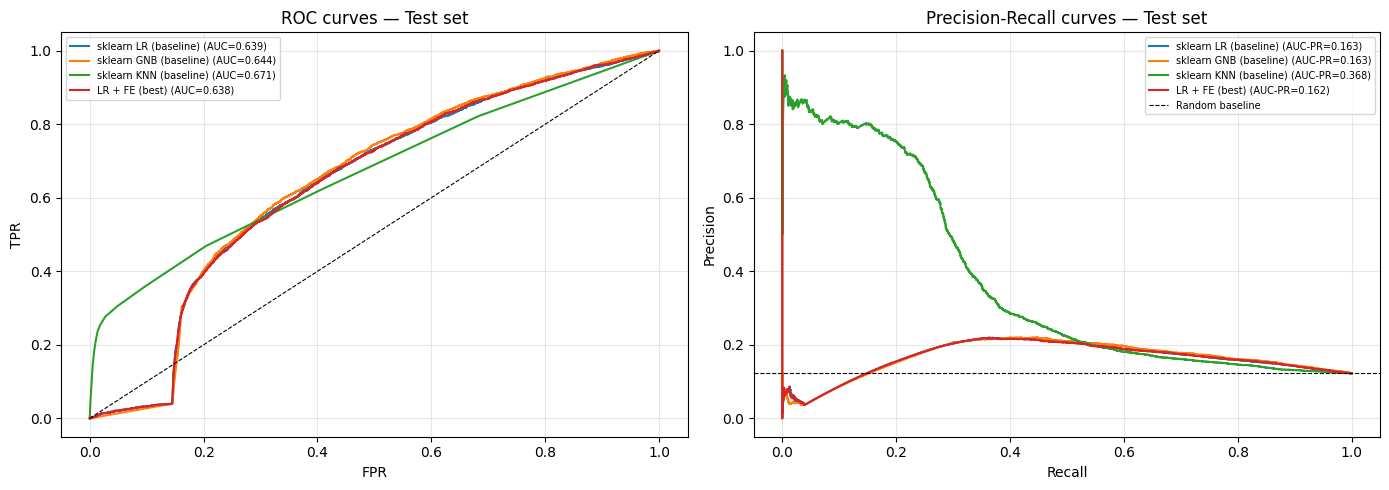

In [29]:
%matplotlib inline

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
ax = axes[0]
for name, (m, Xte) in list(all_models_test.items())[:4]:
    prob = m.predict_proba(Xte)[:, 1]
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(y_te, prob)
    auc_val = roc_auc_custom(y_te, prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_title("ROC curves — Test set")
ax.legend(fontsize=7)
ax.grid(alpha=0.3)
 
ax = axes[1]
for name, (m, Xte) in list(all_models_test.items())[:4]:
    prob = m.predict_proba(Xte)[:, 1]
    prec, rec, _ = precision_recall_curve_custom(y_te, prob)
    aucpr = auc_pr_custom(y_te, prob)
    order = np.argsort(rec)
    ax.plot(rec[order], prec[order], label=f"{name} (AUC-PR={aucpr:.3f})", linewidth=1.5)
ax.axhline(y_te.mean(), color="k", linestyle="--", linewidth=0.8, label="Random baseline")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall curves — Test set")
ax.legend(fontsize=7)
ax.grid(alpha=0.3)
 
plt.tight_layout()
plt.show()

ROC (левый): все модели примерно одинаковы (AUC 0.638–0.671), KNN чуть лучше. Разрыв небольшой, и на ROC это почти незаметно — потому что ROC хорошо "маскирует" качество на имбалансных данных за счёт огромного числа истинных негативов.     
PR (правый): здесь всё честнее. KNN (AUC-PR=0.368) лучше LR (0.162–0.163). Кривая KNN — она держит высокую precision (~0.8) при низком recall, то есть модель очень осторожна: если авто "лимон", она почти всегда права, но находит лишь малую долю лимонов.

Почему KNN бьет остальные модели в данном случае:

1. Concept drift — главная причина  
На тесте — это май–декабрь 2010 (рынок меняется). LR обучился на паттернах 2009 года и экстраполирует линейную границу в новое распределение. KNN же не экстраполирует вообще — он просто смотрит на ближайших соседей в пространстве признаков. Если структура локальных соседств сохраняется даже при сдвиге глобального распределения, KNN адаптируется лучше.
2. KNN работает как ансамбль локальных решений  
LR ищет одну глобальную гиперплоскость. Если граница между "лимонами" и нормальными авто нелинейна (а это скорее всего так — комбинация пробега, марки, цены и возраста), KNN автоматически её улавливает без всякого feature engineering.
3. LR + FE добавил "шум" для теста  
Feature engineering (groupby-средние по Make/Model) был посчитан на train 2009 года. В тесте 2010 года эти средние уже устарели — появились новые дилеры, изменились цены. LR с FE получил "просроченные" признаки, KNN — нет, он просто смотрит на сырые числа.
4. KNN не делает допущений о форме данных   
LR предполагает линейность в пространстве признаков. KNN — непараметрический, и при достаточном числе обучающих примеров он сходится к оптимальному байесовскому классификатору.